# **Sentiment Analysis | Naive Bayes**

Model prediksi kelompok komentar pengguna menggunakan algoritma Naive Bayes.

## 1. Data Understanding 

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import tkinter as tk 
from PIL import Image, ImageTk
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
from tkinter import messagebox

### 1.2 Read Dataset

In [2]:
# Importing dataset 
try:
    sentiment = pd.read_csv('dataset_penyisihan_bdc_2024.csv', sep=';')
    print('Dataset complacated.')
except ValueError as e:
    print(f'\nError: {e}')


Dataset complacated.


In [3]:
# Show the 5 top rows of dataset
print('\n5 top rows of dataset:')
sentiment.head()


5 top rows of dataset:


,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [4]:
# Show the information of dataset
print('\nInformation of dataset:')
sentiment.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5000 non-null   str  
 1   label   5000 non-null   str  
dtypes: str(2)
memory usage: 78.3 KB


In [5]:
# show the diimensional data
print('\nDimensional data:')
print('Number of rows:', sentiment.shape[0])
print('Number of columns:', sentiment.shape[1])


Dimensional data:
Number of rows: 5000
Number of columns: 2


In [6]:
# Show the number of missing values and duplicated data 
print('\nNumber of missing values:', sentiment.isnull().sum().sum())
print('\nNumber of duplcated data:', sentiment.duplicated().sum())


Number of missing values: 0

Number of duplcated data: 381


In [7]:
# Show the rows that have a duplicated data
print('\nRows that have a duplicated data:')
sentiment[sentiment.duplicated(keep=False)]


Rows that have a duplicated data:


,text,label
17,RT Trending On Twitter ( X) Anies Bubble merok...,Sosial Budaya
20,RT Abah Anies ingin mengangkat martabat petani...,Sosial Budaya
38,"RT Anak Muda Indonesia, the future of this nat...",Ideologi
40,"RT According to Prabowo, Gaza is opressed beca...",Pertahanan dan Keamanan
41,"RT Ini kejam, warga disitu sudah bersedia diba...",Sosial Budaya
...,...,...
4917,"RT Ini kejam, warga disitu sudah bersedia diba...",Sosial Budaya
4933,RT Karena program pak anies yg ini. Bapak gw j...,Sumber Daya Alam
4955,RT Ekonom: Program Makan Siang dan Susu Gratis...,Ekonomi
4971,"RT menjelang tengah malam ini, aku mau ucapkan...",Ideologi


In [8]:
# Show the number of unique vaulues
print('\nNumber of unique values per columns:')
sentiment.nunique()


Number of unique values per columns:


text     4583
label       8
dtype: int64

In [9]:
# Show the unique values of label
print('\nUnique values of target:')
sentiment['label'].unique().tolist()


Unique values of target:


['Sumber Daya Alam',
 'Politik',
 'Demografi',
 'Pertahanan dan Keamanan',
 'Ideologi',
 'Ekonomi',
 'Sosial Budaya',
 'Geografi']

#### **Conclution of Data Understanding** 

1. Dataset memiliki 5000 baris data dengan  2 kolom.
2. Dari 5000 baris data, terdapat 4583 nilai unik. Itu artinya, ada total 38 nilai duplikat yang harus ditangani.
3. Tidak terdapat missing value pada dataset ini. 
4. Terdapat 8 jenis/kelompok komentar pada dataset ini.

## 2. Exploratory Data Analysis 

### 2.1 Multivariate Analysis 

#### Statistical Analysis

In [10]:
# Show the statistical summary analysis 
print('\nStatistical summary:')
sentiment.describe()


Statistical summary:


,text,label
count,5000,5000
unique,4583,8
top,RT Abah Anies ingin mengangkat martabat petani...,Politik
freq,42,2972


In [11]:
# Number of duplicated data 
print('Number of duplicated data:', sentiment.duplicated().sum())
dup = 5000 - 4538 
print('Number of sentiment that have a same comment:', dup)

different_label = dup - 381
print('Number of sentiment that have a same comment but have not the same label:', different_label)

Number of duplicated data: 381
Number of sentiment that have a same comment: 462
Number of sentiment that have a same comment but have not the same label: 81


- Insight:
1. Ada 81 komen yang sama dengan label yang berbeda. ini bisa membingungkan model.
2. Komentar terbanyak adalah komentar tentang politik dengan jumlah 2.972 komentar. 
3. Komentar 'RT Abah Anies ingin mengangakat...' memiliki jumlah 42 komentar. 

- Solusi:
1. Penanganan data duplikat dengan dihapus. 


In [12]:
# Lenght of text 
sentiment['text_len'] = sentiment['text'].apply(len)

# Lenght word per text
sentiment['word_len'] = sentiment['text'].apply(lambda x: len(str(x).split()))

# Encoding label using mapping technique
sentiment['label_num'] = sentiment['label'].map({
    'Sumber Daya Alam': 0,
    'Politik': 1,
    'Demografi': 2,
    'Pertahanan dan Keamanan': 3,
    'Ideologi': 4,
    'Ekonomi': 5,
    'Sosial Budaya': 6,
    'Geografi': 7,
})

In [13]:
# Separate the catecorial and numerical columns
num_cols = sentiment.select_dtypes(include=['int64', 'float64'])
cat_cols = sentiment.select_dtypes(include=['object', 'category'])

/tmp/ipykernel_70504/3416071028.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sentiment.select_dtypes(include=['object', 'category'])


#### Statistical Sumarry for Numerical Columns

In [14]:
# statistical summary for numerical columns
print('\nStatistical Summary for Numerical Columns:')
num_cols.describe()


Statistical Summary for Numerical Columns:


,text_len,word_len,label_num
count,5000.000000,5000.000000,5000.000000
mean,268.815600,32.752800,2.278600
std,314.762818,40.228539,1.926168
min,45.000000,3.000000,0.000000
25%,168.000000,19.000000,1.000000
50%,217.000000,25.000000,1.000000
75%,280.000000,36.000000,4.000000
max,4893.000000,728.000000,7.000000


- Insight:
1. Fitur panjang kata dan huruf, memiliki standart deviation yang cukup besar. Artinya nilai rata-rata mereka cukup jauh dengan nilai maxnya.
2. Nilai median dengan nilai max pada fitur 'text_len' dan 'word_len' memiliki selisih yang cukup jauh. Ada kemungkinan outlier.

- Solusi:
1. Penanganan outlier menggunakan mean, median, modus atau log transform.

#### Correlation Analysis

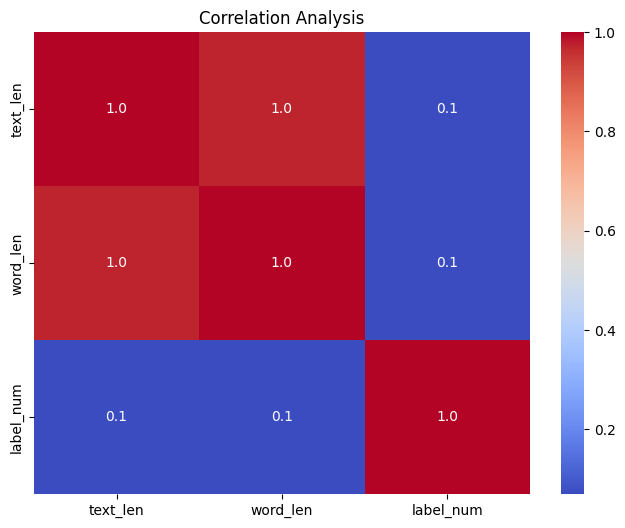

In [15]:
# Show the correlation visualization 
correlation = sentiment[['text_len', 'word_len', 'label_num']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Analysis')
plt.show()

- Insight: 
1. Ternyata, panjang atau pendeknya kalimat atau kata, memiliki korelasi hampir 0.0, yang artinya itu tidak ada hubungan. Panjang pendeknya komentar tertentu, tidak menjamin komentar tersebut masuk kedalam label tertentu.
2. Semakin banyak kata, tentunya semakin banyak kata. 

- Solusi:
1. Saat di permodelan, akan menggukan salah satu dari fitur 'word_len' atau 'text_len' karena memiliki hubungan ynag tinggi.

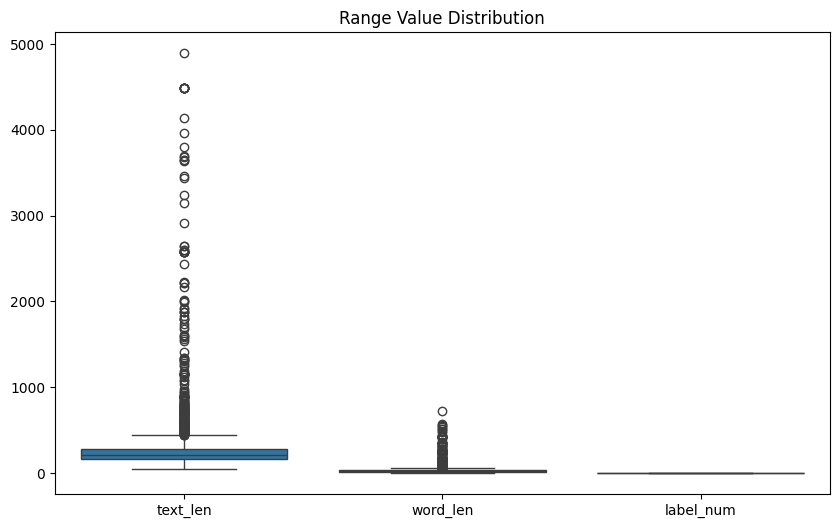

In [16]:
# Shwo boxplot analysis
plt.figure(figsize=(10,6))
sns.boxplot(num_cols)
plt.title('Range Value Distribution')
plt.show()

In [17]:
# Show the number of outliers
num_cols = ['text_len', 'word_len']
results = []

for col in num_cols:
    Q1 = sentiment[col].quantile(0.25)
    Q3 = sentiment[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((sentiment[col] < lower_bound) | (sentiment[col] > upper_bound)).sum()
    
    results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Upper Bound': upper_bound,
        'Outliers Count': outliers_count,
        'Percentage': f"{(outliers_count / len(sentiment) * 100):.2f}%"
    })

iqr_table = pd.DataFrame(results)
print(iqr_table)

    Feature     Q1     Q3    IQR  Upper Bound  Outliers Count Percentage
0  text_len  168.0  280.0  112.0        448.0             278      5.56%
1  word_len   19.0   36.0   17.0         61.5             250      5.00%


- Insight: 
1. Cukup banyak komentar dengan jumlah kata diluar range. 
2. Cukup banyak komentar dengan panjang huruf diluar range/


### 2.2 Univariate Analysis

#### Target Distribution

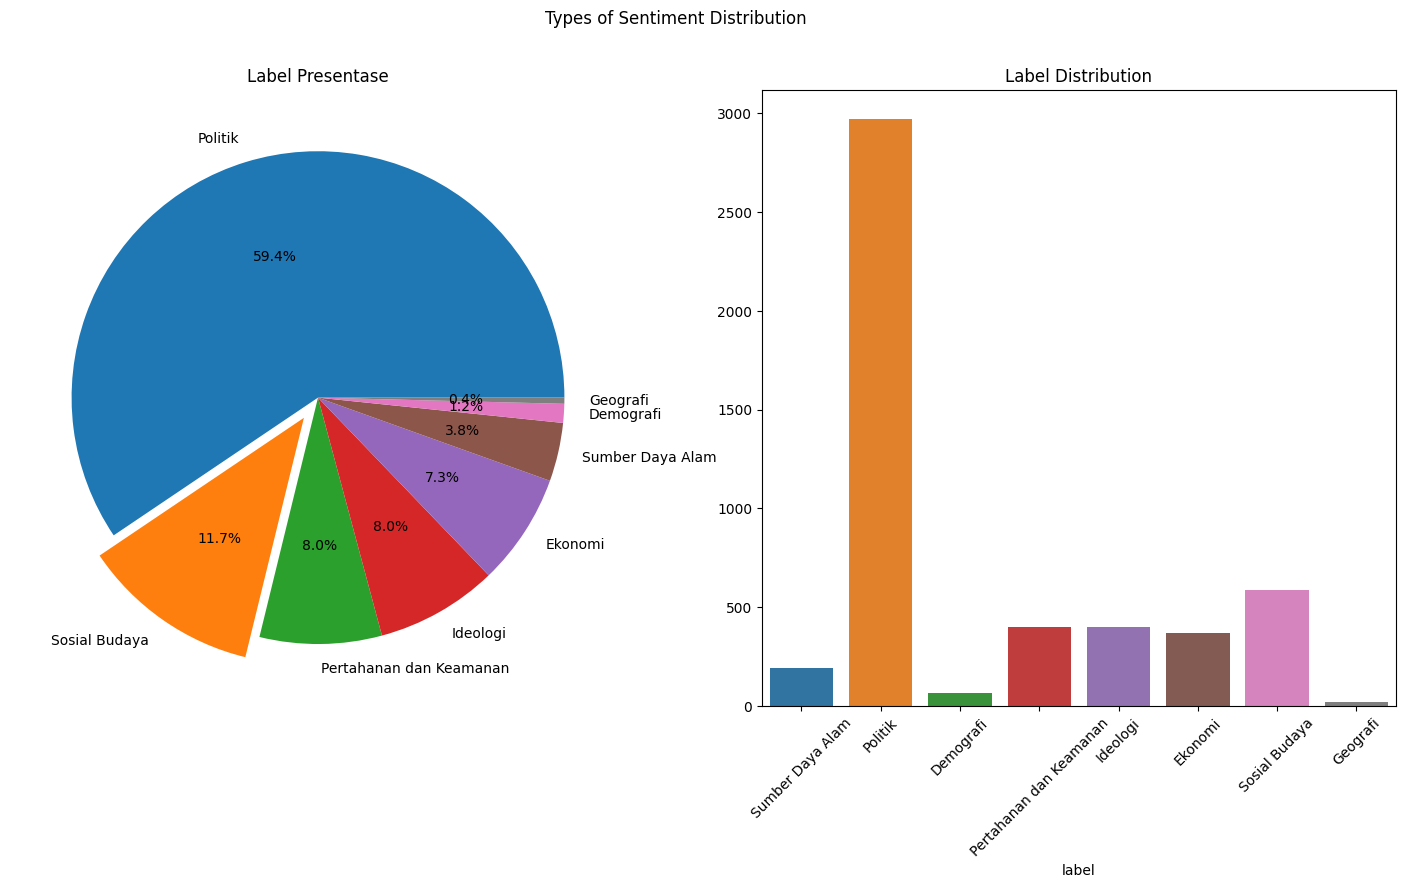

In [18]:
num_labels = sentiment['label'].nunique()
explode_value = [0.1 if i == 1 else 0 for i in range(num_labels)]

f, ax = plt.subplots(1,2, figsize=(18, 8))
sentiment['label'].value_counts().plot.pie(explode=explode_value, autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Label Presentase')
ax[0].set_ylabel('')

sns.countplot(data=sentiment, x='label', hue='label', ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title('Label Distribution')
ax[1].set_ylabel('')

plt.suptitle('Types of Sentiment Distribution')
plt.show()

- Insight: 
1. Target memiliki penyebaran data yang immbalance. Dimana komentar politik mendominasi lebih dari 50%. Sedangkan, target minoritas dengan jumlah paling sedikit adalah komentar Geografi. 

- Solusi:
1. Dilakukan resampling untuk target ini. Karena, model naive bayes sensitif terhadap target immbalance.

#### Feature Distribution

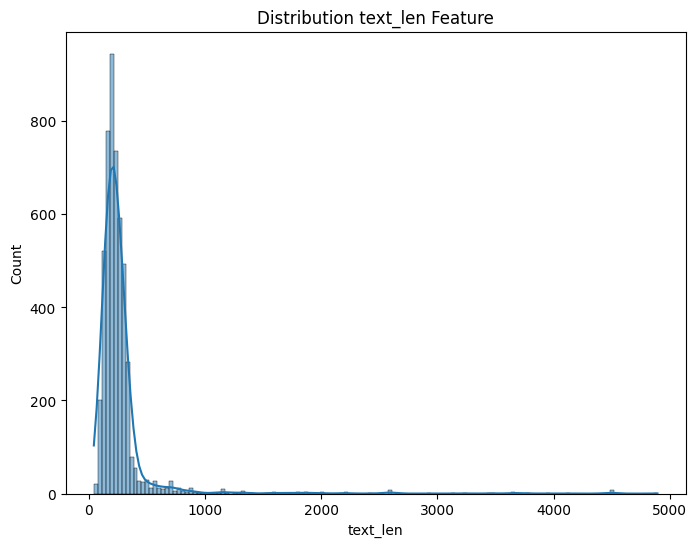

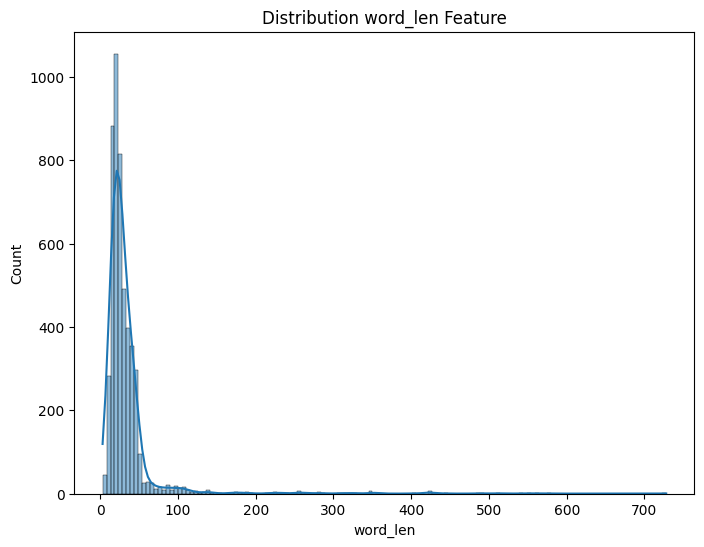

In [19]:
# Show the distribution per featrue 
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=sentiment, x=col, kde=True)
    plt.title(f'Distribution {col} Feature')
    plt.show()

- Insight:
1. Penyebaran nilai pada fitur panjang kata dan panjang kata cenderumg miring ke kanan. Dimana, panjang kata komentar cenderung kurang dari 1000, dan panjang huruf kurang dari 100.


### 2.3 Bivariate Analysis

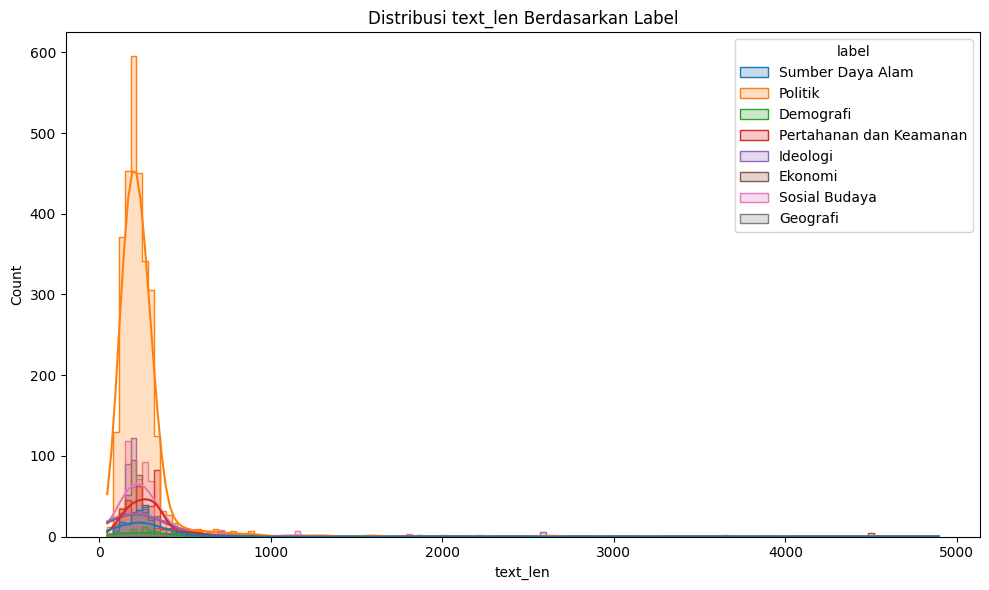

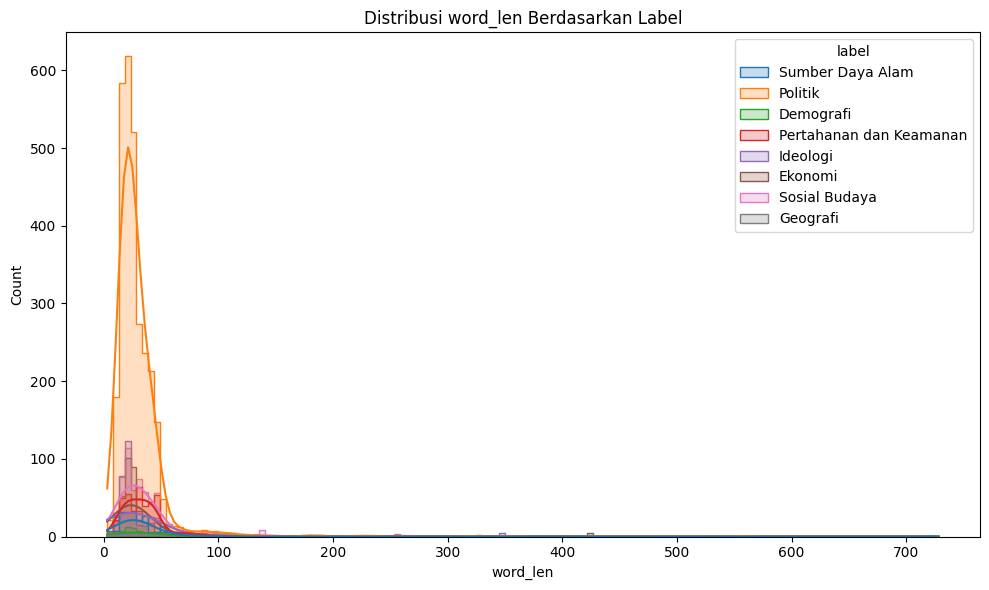

In [20]:
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=sentiment, x=col, hue='label', element="step", kde=True)
    plt.title(f'Distribusi {col} Berdasarkan Label')
    plt.tight_layout()
    plt.show()

- Insight:
1. Jumlah kata dan huruf dari komentar dataset yang memiliki nilai yang besar, kecenderungan komentar politik.

## 3. Data Preprocessing 

### 3.1 Handling Duplicated Data 


In [21]:
# Handling duplicated data with drop the one of the duplicated data 
sentiment = sentiment.drop_duplicates(keep='first')
print('\nNumber of duplicated data:', sentiment.duplicated().sum())


Number of duplicated data: 0


### 3.2 Text Preprocessing  

In [22]:
# Ambil stopword Indo dari Sastrawi
stop_factory = StopWordRemoverFactory()
indo_stopwords = set(stop_factory.get_stop_words())

# Ambil stopword Inggris dari NLTK
try:
    eng_stopwords = set(nltk.corpus.stopwords.words('english'))
except:
    nltk.download('stopwords')
    eng_stopwords = set(nltk.corpus.stopwords.words('english'))

# Gabungkan keduanya menjadi satu set agar pencarian kata sangat cepat
combined_stopwords = indo_stopwords.union(eng_stopwords)

def text_preprocessing(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Case Normalization
    text = text.lower()
    
    # 2. Cleaning (Hapus Tanda Baca & Angka)
    punctuation = '''!()-[]{};:'"\,<>./?@#$%^&*_~0123456789'''
    clean_text = ""
    for char in text:
        if char not in punctuation:
            clean_text += char
        else:
            clean_text += " "
    
    # 3. Tokenization & 4. Stopword Removal
    tokens = clean_text.split()
    tokens_no_stop = [word for word in tokens if word not in combined_stopwords]
    
    # 5. Gabungkan kembali
    return " ".join(tokens_no_stop)

# --- LANGKAH 2: Eksekusi ke DataFrame ---
print("Memulai preprocessing...")
sentiment['text_cleaned'] = sentiment['text'].apply(text_preprocessing)
print("Selesai!")

# Cek hasil

print(sentiment[['text', 'text_cleaned']].head())

Memulai preprocessing...


<>:23: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:23: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/tmp/ipykernel_70504/3288644899.py:23: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  punctuation = '''!()-[]{};:'"\,<>./?@#$%^&*_~0123456789'''


Selesai!
                                                text  \
0  Kunjungan Prabowo ini untuk meresmikan dan men...   
1  RT Anies dapat tepuk tangan meriah saat jadi R...   
2  @CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...   
3  RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...   
4  Anies Baswedan Harap ASN termasuk TNI dan Polr...   

                                        text_cleaned  
0  kunjungan prabowo meresmikan menyerahkan proye...  
1  rt anies tepuk tangan meriah jadi rektor mewaj...  
2  ciqxqwgat tmtx ocatxjovq vv heyaiogmfg y= emng...  
3  rt l r xfbw wgbxrpsj hhztbqvgx qtfwrg zmhk q= ...  
4  anies baswedan harap asn termasuk tni polri pe...  


In [23]:
input_komentar = [str(text).split() for text in sentiment['text_cleaned']]
data_untuk_tfidf = {"comment": input_komentar}

In [24]:
def compute_tf_idf_manual(dataset):
    # 1. Hitung frekuensi kata (TF)
    counts = []
    for comment in dataset["comment"]:
        row_counts = {}
        for word in comment:
            row_counts[word] = row_counts.get(word, 0) + 1
        counts.append(row_counts)

    # 2. Buat Matrix TF
    tf = pd.DataFrame(counts).fillna(0)
    
    # 3. Normalisasi TF (Peredam Outlier)
    # Membagi setiap baris dengan total kata di baris tersebut
    tf = tf.div(tf.sum(axis=1), axis=0).fillna(0)

    # 4. Hitung IDF (Tanpa library math, pakai numpy)
    # df = jumlah dokumen yang mengandung kata t
    df = (tf > 0).sum(axis=0)
    # idf = log(N / (df + 1))
    idf = np.log(len(dataset["comment"]) / (df + 1))

    # 5. Hasil Akhir TF-IDF
    return tf * idf

# Eksekusi
tf_idf_hasil = compute_tf_idf_manual(data_untuk_tfidf)

# Tampilkan jumlah vocab yang berhasil dideteksi
print(f"Total Vocab (Fitur) yang ditemukan: {tf_idf_hasil.shape[1]} kata")

Total Vocab (Fitur) yang ditemukan: 26651 kata


In [25]:
word_scores = tf_idf_hasil.sum(axis=0).sort_values(ascending=False)

print("Variabel word_scores berhasil dibuat!")
print(word_scores.head()) # Menampilkan 5 kata teratas

Variabel word_scores berhasil dibuat!
prabowo    88.770830
ganjar     85.921160
anies      81.314021
mahfud     71.010883
pranowo    70.939887
dtype: float64


/tmp/ipykernel_70504/2357371571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


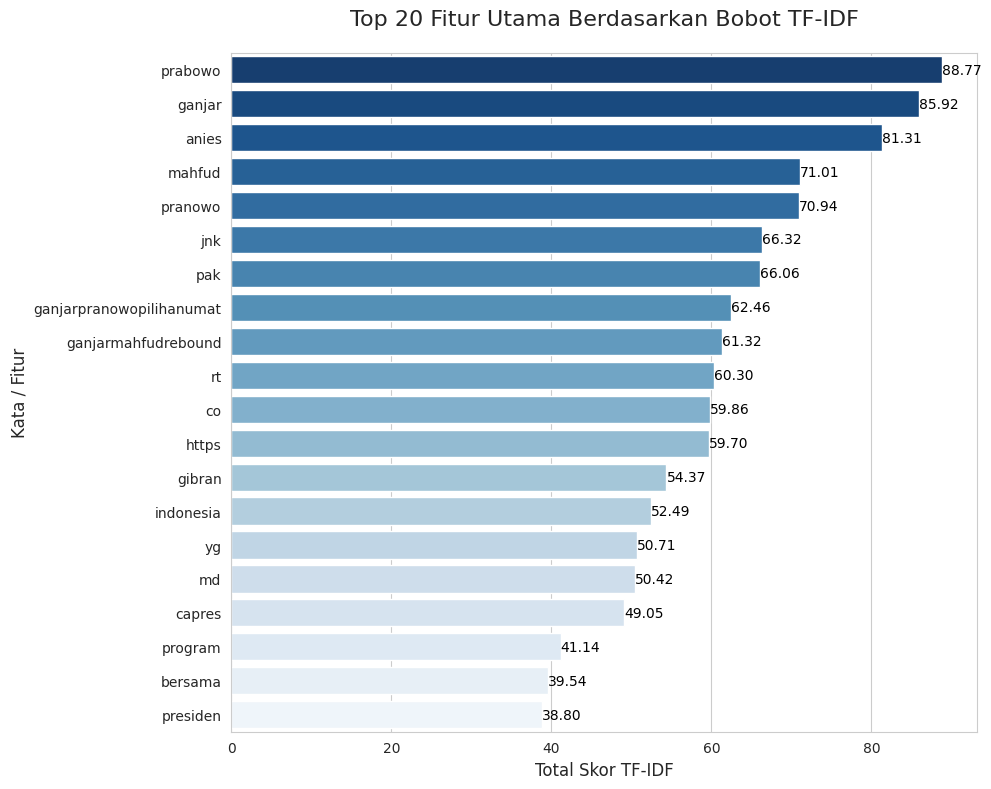

In [26]:
top_20_words = word_scores.head(20)
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=top_20_words.values, 
    y=top_20_words.index, 
    palette="Blues_r" 
)

for i, v in enumerate(top_20_words.values):
    ax.text(v + 0.01, i, f'{v:.2f}', color='black', va='center', fontsize=10)

plt.title('Top 20 Fitur Utama Berdasarkan Bobot TF-IDF', fontsize=16, pad=20)
plt.xlabel('Total Skor TF-IDF', fontsize=12)
plt.ylabel('Kata / Fitur', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_70504/480787000.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10_words.values, y=bottom_10_words.index, palette='Reds_r')


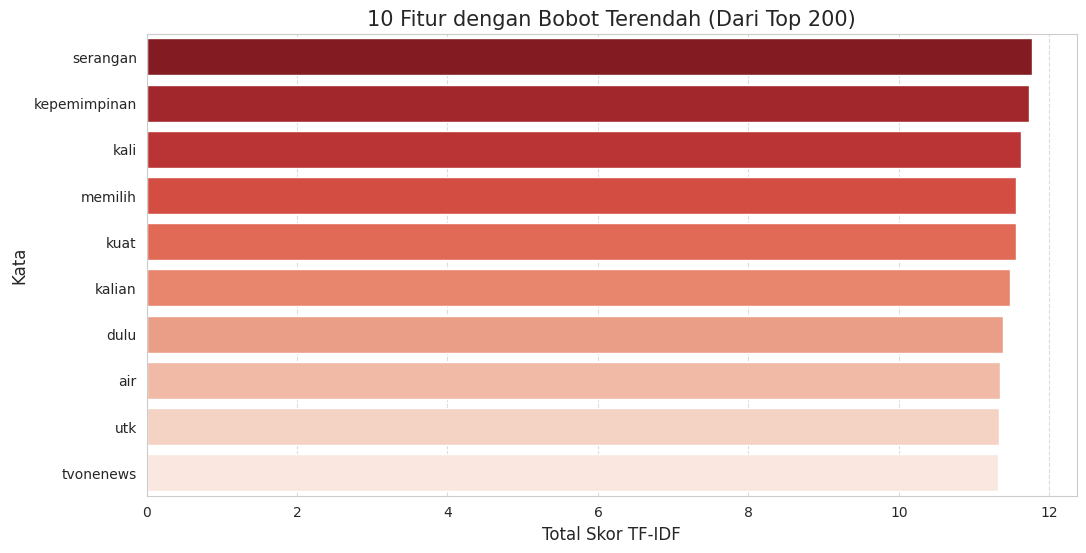

In [27]:

bottom_10_words = word_scores.head(200).tail(10)

plt.figure(figsize=(12, 6))
# Menggunakan warna merah (Reds_r) untuk menunjukkan bobot rendah
sns.barplot(x=bottom_10_words.values, y=bottom_10_words.index, palette='Reds_r')

plt.title('10 Fitur dengan Bobot Terendah (Dari Top 200)', fontsize=15)
plt.xlabel('Total Skor TF-IDF', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 4. Model

In [28]:
X = tf_idf_hasil
y = sentiment['label_num']

In [29]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for classes in np.unique(y):
        class_idx = np.where(y == classes)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train  = pd.concat(x_train).reset_index(drop=True)
    X_test  = pd.concat(x_test).reset_index(drop=True)
    y_train  = pd.concat(y_train).reset_index(drop=True)
    y_test  = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [30]:
X_train, X_test, y_train, y_test = split_data(X, y)

for var in [X_train, X_test, y_train, y_test]:
    print(var.shape)

(3692, 26651)
(927, 26651)
(3692,)
(927,)


In [31]:
def prior(y, classes):
    n_sample = len(y)
    prior = np.zeros(len(classes))

    for idx, c in enumerate(classes):
        prior[idx] = np.sum(y == c) / n_sample

        return prior

In [32]:
def likehood(X, y, classes, alpha=1.0):
    n_feature = X.shape[1]
    n_classes = len(classes)

    likelihood = np.zeros((n_classes, n_feature))

    for idx, c in enumerate(classes):
        X_c = X[y == c]
        total_count = np.sum(X_c)
        feature_count = np.sum(X_c, axis=0)
        likelihood[idx, :] = (feature_count + alpha) / (total_count + alpha & n_feature)
        
        return likelihood

In [33]:
class naivebayes:
    def init(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.prior = None
        self.likelihood = None
        self.log_prior = None
        self.log_likelihood = None

    def fit(self, X, y):
        # Konversi ke numpy array
        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values
        
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        # 1. Hitung Prior P(c)
        self.prior = np.zeros(n_classes)
        for idx, c in enumerate(self.classes):
            self.prior[idx] = np.sum(y == c) / len(y)

        # 2. Hitung Likelihood P(x|c)
        self.likelihood = np.zeros((n_classes, n_features))
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            
            # Laplace Smoothing Calculation
            feature_count = np.sum(X_c, axis=0)
            total_count = np.sum(X_c)
            
            self.likelihood[idx, :] = (feature_count + self.alpha) / (total_count + (self.alpha * n_features))

        # 3. Transformasi ke Log (DILUAR LOOP)
        self.log_prior = np.log(self.prior + 1e-10)
        self.log_likelihood = np.log(self.likelihood + 1e-10)

        return self # <--- Indentasi sudah benar, di luar loop

    def predict_single(self, x):
        # Perhitungan menggunakan dot product agar lebih cepat
        # log(P(c|x)) = log(P(c)) + sum(x * log(P(x|c)))
        posteriors = []
        for idx in range(len(self.classes)):
            log_p = self.log_prior[idx]
            log_l = np.sum(x * self.log_likelihood[idx])
            posteriors.append(log_p + log_l)
        return self.classes[np.argmax(posteriors)]

    def predict(self, X):
        if hasattr(X, 'values'): X = X.values
        return np.array([self.predict_single(x) for x in X])
    
    def score(self, X, y):
        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values
        y_pred = self.predict(X)
        return np.sum(y == y_pred) / len(y)

    def predict_probs(self, X):
        if hasattr(X, 'values'): X = X.values
        probs = np.zeros((X.shape[0], len(self.classes)))
        for i, x in enumerate(X):
            log_post = np.array([self.log_prior[idx] + np.sum(x * self.log_likelihood[idx]) 
                                for idx in range(len(self.classes))])
            log_post -= np.max(log_post) # Stability trick
            exp_p = np.exp(log_post)
            probs[i] = exp_p / np.sum(exp_p)
        return probs

In [34]:
def random_oversampling(X, y):
    """Random oversampling dengan NumPy arrays"""
    # ✅ CONVERT KE NUMPY
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    
    classes = np.unique(y)
    class_counts = [np.sum(y == c) for c in classes]
    max_count = max(class_counts)
    
    X_balanced_list = []
    y_balanced_list = []
    
    for c in classes:
        # Get data untuk kelas c
        mask = (y == c)
        X_class = X[mask]
        y_class = y[mask]
        
        # Oversample
        if len(X_class) < max_count:
            indices = np.random.choice(len(X_class), max_count, replace=True)
            X_balanced_list.append(X_class[indices])
            y_balanced_list.append(y_class[indices])
        else:
            X_balanced_list.append(X_class)
            y_balanced_list.append(y_class)
    
    # Stack arrays
    X_balanced = np.vstack(X_balanced_list)
    y_balanced = np.hstack(y_balanced_list)
    
    return X_balanced, y_balanced

In [ ]:
X_rand, y_rand = random_oversampling(X.values, y)

In [ ]:
model = naivebayes()
model.fit(X, y)

In [ ]:
prediction = model.predict(X_test.values)
probabilitas = model.predict_probs(X_test.values)

In [ ]:
acc = model.score(X_test.values, y_test)
print(acc)

None


In [ ]:
# Tambahkan parameter 'model' ke dalam fungsi
def evaluate(model, X_eval, y_eval, y_pred, title='Evaluation'):
    y_true = np.array(y_eval)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    
    # Menghitung Accuracy menggunakan model yang spesifik dipassing
    accuracy = model.score(X_eval.values, y_true)
    
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    # Macro Averaging
    m_precision = np.mean(precision)
    m_recall = np.mean(recall)
    m_f1 = np.mean(f1)

    print(f'--- {title} ---')
    print(f'Accuracy  : {accuracy}')
    print(f'Precision : {m_precision}')
    print(f'Recall    : {m_recall}')
    print(f'F1 Score  : {m_f1}\n')

In [ ]:
y_pred_train = model.predict(X_train.values)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 4619 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    4619 non-null   str  
 1   label   4619 non-null   int64
dtypes: int64(1), str(1)
memory usage: 108.3 KB


In [5]:
def submit():
    input_data = entry.get()
    if not input_data.strip():
        messagebox.showwarning('Warning', 'Masukan Komentar!')
        return
    try:
        labels = {
            0: 'Politik', 1: 'Sosial Budaya', 2: 'Ideologi', 
            3: 'Pertahanan dan Keamanan', 4: 'Ekonomi', 
            5: 'Sumber Daya Alam', 6: 'Demografi', 7: 'Geografi'
        }

        pred = model.predict(input_data)
        messagebox.showinfo(f'Hasil Prediksi: {pred}')
    except Exception as e:
        messagebox.showerror('Error', f'Terjadi kesalahan: {e}')

root = tk.Tk()
root.title('Prediksi Kategori Komentar')
root.configure(bg='#131313')
root.geometry('500x500')

frame_tengah = tk.Frame(root, bg='#131313')
frame_tengah.place(relx=0.5, rely=0.4, anchor='center')

# logo
container_logo = tk.Frame(frame_tengah,
                          bg='#131313')
container_logo.pack(pady=10)

img = Image.open('robot.png').resize((80,80))
logo = ImageTk.PhotoImage(img)
label_logo = tk.Label(container_logo,
                      image=logo,
                      bg='#131313')
label_logo.image = logo
label_logo.pack()

# Body
title_label = tk.Label(frame_tengah,
                       text='Prediksi Kategori Komentar', 
                       font=('Helvetica', 22, 'bold'), 
                       bg='#131313', 
                       fg='#FFFFFF')
title_label.pack(pady=10)

entry_label = tk.Label(frame_tengah, 
                       text='Masukan Komentar', 
                       font=('Helvetica', 10), 
                       bg='#131313', 
                       fg='#FFFFFF')
entry_label.pack(pady=5)

entry = tk.Entry(frame_tengah, 
                 fg='#FFFFFF', 
                 bg='#222222', 
                 font=('Helvetica', 18), 
                 insertbackground='white', 
                 bd=0)
entry.pack(pady=10, ipady=5)

pred_btn = tk.Button(frame_tengah, 
                     text='Prediksi', 
                     font=('Helvetica', 12, 'bold'), 
                     bg='#1D9BF0', fg='#FFFFFF', 
                     command=submit, 
                     bd=0, 
                     width=15)
pred_btn.pack(pady=20)

# footer
footer_frame = tk.Frame(root, 
                        bg='#131313')
footer_frame.pack(side='bottom', fill='x', pady=10)

line = tk.Frame(footer_frame, 
                height=1, 
                width=400, 
                bg='#444444')
line.pack(pady=5)

label_bottom = tk.Label(footer_frame, 
                        text='Sincerely SMKN 2 Singosari',
                        font=('Helvetica', 8),
                        fg="#666666",
                        bg='#131313')
label_bottom.pack()

root.mainloop()

## 5. Evaluation

## 6. Visualization 

## 7. GUI 

## 8. Calculation